<a href="https://colab.research.google.com/github/ceyhun2306/data-analysis-python/blob/main/Student_Exam_Performance_Dataset_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
#!/bin/bash
!kaggle datasets download grandmaster07/student-exam-performance-dataset-analysis

Dataset URL: https://www.kaggle.com/datasets/grandmaster07/student-exam-performance-dataset-analysis
License(s): CC0-1.0
100% 93.9k/93.9k [00:00<00:00, 46.8MB/s]



In [ ]:
!unzip /content/student-exam-performance-dataset-analysis.zip

Archive:  /content/student-exam-performance-dataset-analysis.zip
  inflating: StudentPerformanceFactors.csv  


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/StudentPerformanceFactors.csv")
df

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68


In [ ]:
df.shape

(6607, 20)

# Descriptive Statistics — Key

In [ ]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000



- All 7 numeric columns have 6607 non-null values. Missing values exist
  only in categorical columns and are not shown here.

- Most columns show symmetrical distributions where mean ≈ median,
  indicating minimal skewness and stable, well-behaved data.

- Exam_Score has a notably small std (3.89), meaning most students scored
  between 63–71 despite having very different backgrounds and study habits.
  The analysis will focus on identifying what drives even small differences
  in score.

- Attendance minimum is exactly 60%, suggesting students below this
  threshold were not permitted to sit the exam and are absent from
  the dataset.

- The percentile intervals in several columns are suspiciously uniform
  (e.g. Attendance: 70 / 80 / 90), which may indicate a synthetic or
  semi-synthetic dataset. This does not affect the analysis but is
  worth noting.

- Exam_Score max = 101 is a likely data entry error and will be
  addressed during data cleaning.

# Data Types & Missing Values — Key Findings

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [ ]:
df.isna().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0



- All 20 columns have correct data types: 7 numeric columns are int64
  and 13 categorical columns are object. No type conversion is needed.

- 17 out of 20 columns are complete with zero missing values.

- Missing values exist in 3 columns:
  - Teacher_Quality: 78 missing (1.18%)
  - Distance_from_Home: 67 missing (1.01%)
  - Parental_Education_Level: 90 missing (1.36%)

- Although the missing percentages appear small, these columns will be
  used in the analysis, so a filling strategy must be applied rather
  than dropping the rows. The most appropriate approach for ordinal
  categorical columns is to fill with the mode or introduce an
  "Unknown" category to preserve transparency.

# Value Counts — Key Findings

In [ ]:
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))


Parental_Involvement:
Parental_Involvement
Medium    3362
High      1908
Low       1337
Name: count, dtype: int64

Access_to_Resources:
Access_to_Resources
Medium    3319
High      1975
Low       1313
Name: count, dtype: int64

Extracurricular_Activities:
Extracurricular_Activities
Yes    3938
No     2669
Name: count, dtype: int64

Motivation_Level:
Motivation_Level
Medium    3351
Low       1937
High      1319
Name: count, dtype: int64

Internet_Access:
Internet_Access
Yes    6108
No      499
Name: count, dtype: int64

Family_Income:
Family_Income
Low       2672
Medium    2666
High      1269
Name: count, dtype: int64

Teacher_Quality:
Teacher_Quality
Medium    3925
High      1947
Low        657
NaN         78
Name: count, dtype: int64

School_Type:
School_Type
Public     4598
Private    2009
Name: count, dtype: int64

Peer_Influence:
Peer_Influence
Positive    2638
Neutral     2592
Negative    1377
Name: count, dtype: int64

Learning_Disabilities:
Learning_Disabilities
No     5912
Yes

- No formatting inconsistencies found. All categories follow consistent
  capitalization with no hidden duplicates (e.g. "Medium" vs "medium").

- Internet_Access and Learning_Disabilities show class imbalance —
  minority groups (No internet: 7.5%, Has disability: 10.5%) are small,
  so conclusions about these groups should be interpreted with caution.

- Distance_from_Home: ~59% Near, ~30% Moderate, ~10% Far — consistent
  with the natural tendency to choose schools close to home.

- dropna=False was used to make NaN values visible. Without it, missing
  values would have been silently excluded from the output.

# Dataset Overview


In [ ]:
df.head(10)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
5,19,88,Medium,Medium,Yes,8,89,Medium,Yes,3,Medium,Medium,Public,Positive,3,No,Postgraduate,Near,Male,71
6,29,84,Medium,Low,Yes,7,68,Low,Yes,1,Low,Medium,Private,Neutral,2,No,High School,Moderate,Male,67
7,25,78,Low,High,Yes,6,50,Medium,Yes,1,High,High,Public,Negative,2,No,High School,Far,Male,66
8,17,94,Medium,High,No,6,80,High,Yes,0,Medium,Low,Private,Neutral,1,No,College,Near,Male,69
9,23,98,Medium,Medium,Yes,8,71,Medium,Yes,0,High,High,Public,Positive,5,No,High School,Moderate,Male,72


This dataset contains 6607 students with 20 features capturing their
study habits, environment, and final exam score.

## Columns

| Column | Type | Description |
|---|---|---|
| Exam_Score | Numeric | Final exam score — target variable |
| Hours_Studied | Numeric | Weekly study hours |
| Attendance | Numeric | Class attendance percentage |
| Sleep_Hours | Numeric | Average nightly sleep hours |
| Previous_Scores | Numeric | Score from a previous exam |
| Tutoring_Sessions | Numeric | Monthly tutoring sessions attended |
| Physical_Activity | Numeric | Weekly physical activity hours |
| Parental_Involvement | Categorical | Level of parental engagement in education |
| Access_to_Resources | Categorical | Access to books, internet and study materials |
| Extracurricular_Activities | Categorical | Participation in activities outside school |
| Motivation_Level | Categorical | Student's self-reported motivation level |
| Internet_Access | Categorical | Whether the student has internet at home |
| Family_Income | Categorical | Socioeconomic level of the student's family |
| Teacher_Quality | Categorical | Student's perceived quality of their teacher |
| School_Type | Categorical | Public or private school |
| Peer_Influence | Categorical | Direction of peer influence on student behavior |
| Learning_Disabilities | Categorical | Whether the student has a learning disability |
| Parental_Education_Level | Categorical | Highest education level completed by parent |
| Distance_from_Home | Categorical | Distance between home and school |
| Gender | Categorical | Gender of the student |

## Notes
- Observational dataset — relationships indicate correlation, not causation.
- Missing values exist in 3 columns and will be handled during cleaning.
- Goal: identify which factors are associated with higher exam scores.

# Outlier Analysis — Key Findings

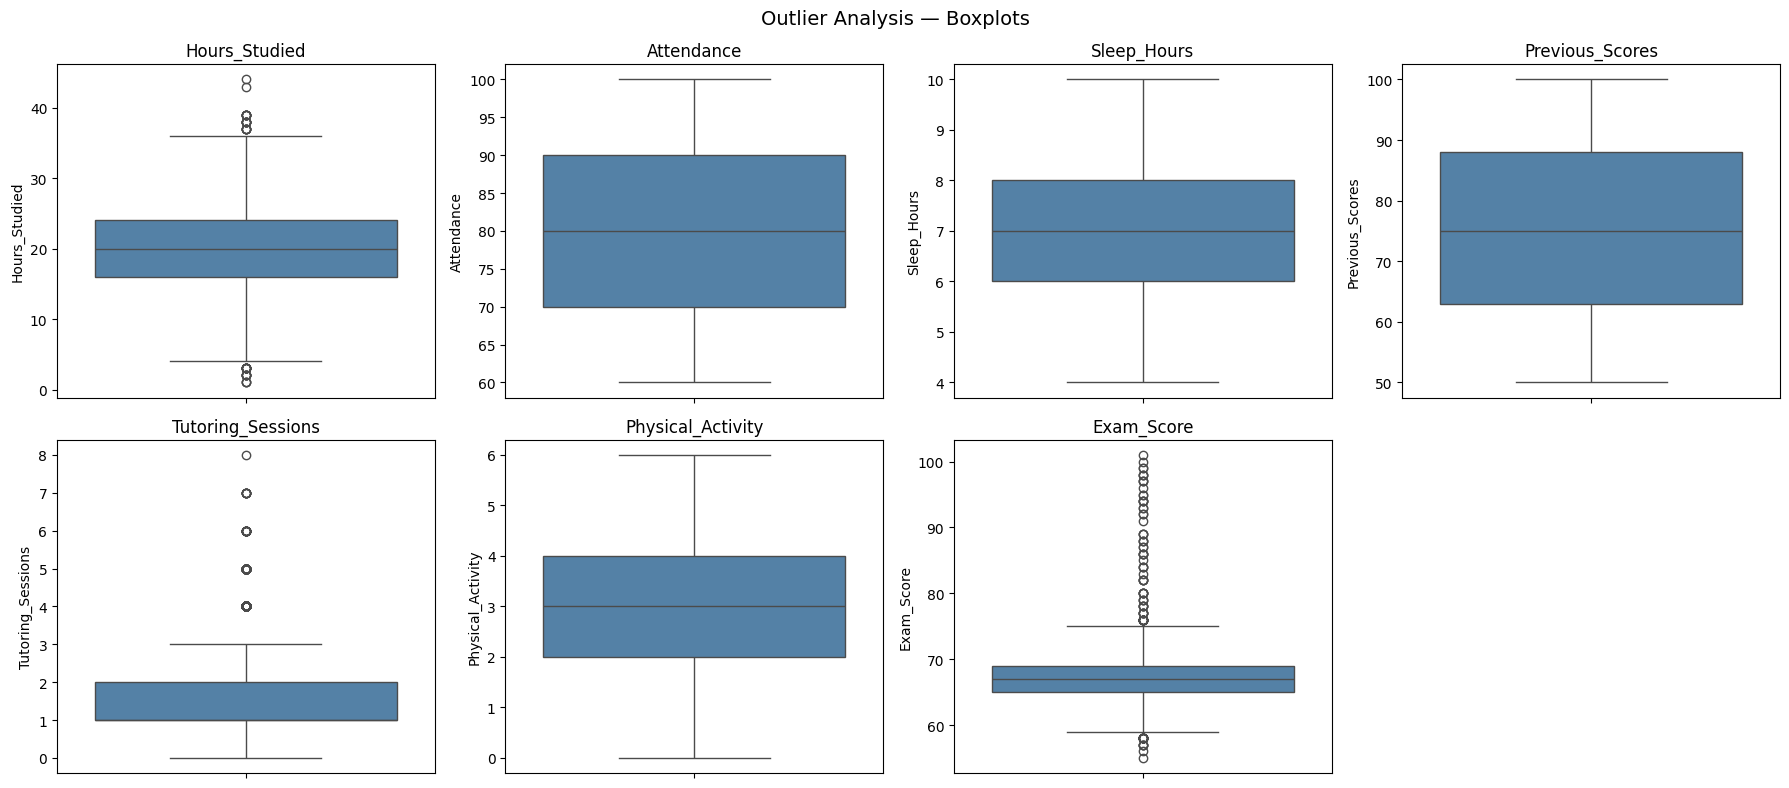

In [ ]:
numeric_cols = ['Hours_Studied', 'Attendance', 'Sleep_Hours',
                'Previous_Scores', 'Tutoring_Sessions',
                'Physical_Activity', 'Exam_Score']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='steelblue')
    axes[i].set_title(col)

axes[-1].set_visible(False)
plt.suptitle('Outlier Analysis — Boxplots', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
df['Exam_Score'] = df['Exam_Score'].replace(101, 100)

- No problematic outliers were found in the dataset. All extreme values
  represent realistic real-world scenarios (e.g. a student studying
  44 hours per week or attending 8 tutoring sessions per month).

- Tutoring_Sessions and Hours_Studied show high-end outliers by the
  IQR formula, but these are genuine data points and were kept
  intentionally.

- One data entry error was identified: Exam_Score contained values of
  101, which is impossible if the exam is scored out of 100. These
  values were replaced with 100 rather than dropped, since removing
  the entire row would have eliminated valid data from high-performing
  students.

# Missing Value Treatment — Key Findings

In [ ]:
df['Teacher_Quality'].fillna(df['Teacher_Quality'].mode()[0], inplace=True)
df['Parental_Education_Level'].fillna(df['Parental_Education_Level'].mode()[0], inplace=True)
df['Distance_from_Home'].fillna(df['Distance_from_Home'].mode()[0], inplace=True)
cols = ['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']
df[cols].isnull().sum()

/tmp/ipykernel_5089/3641022574.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Teacher_Quality'].fillna(df['Teacher_Quality'].mode()[0], inplace=True)
/tmp/ipykernel_5089/3641022574.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(

,0
Teacher_Quality,0
Parental_Education_Level,0
Distance_from_Home,0


- Missing values were found in 3 columns: Teacher_Quality (78),
  Parental_Education_Level (90), and Distance_from_Home (67).

- All three were filled with the mode (most frequent value) because:
  - The columns are categorical with large category sizes, so adding
    70–90 values to the most frequent category has minimal impact.
  - Dropping rows would risk losing data from students who may be
    important to the analysis.

- After treatment, the dataset contains zero missing values.

# Exam Score — Univariate Analysis

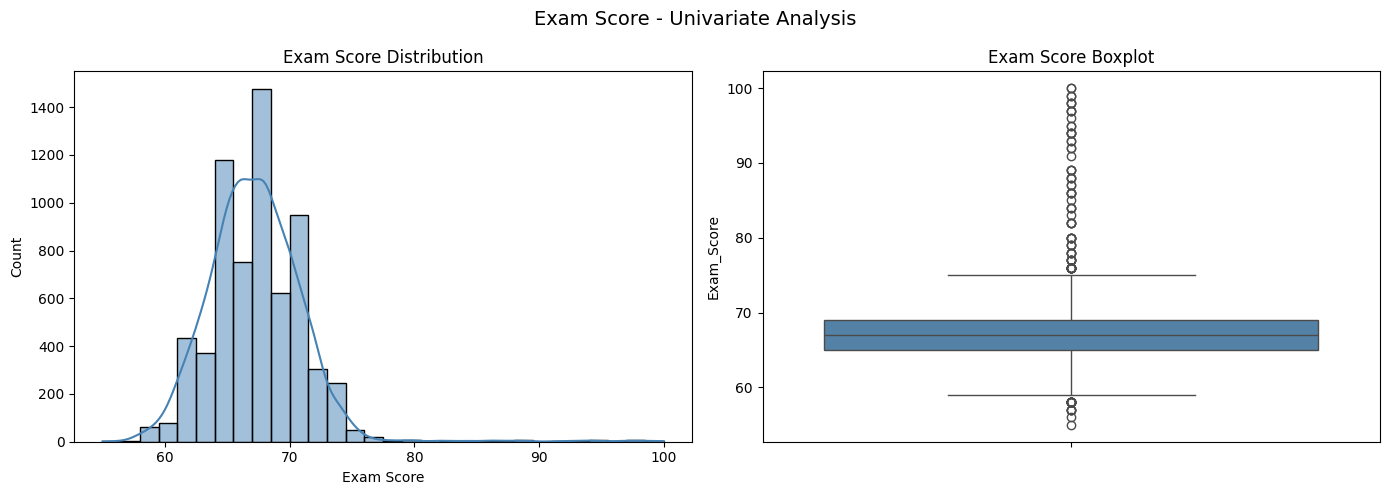

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Exam_Score'], bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Exam Score Distribution')
axes[0].set_xlabel('Exam Score')
axes[0].set_ylabel('Count')

sns.boxplot(y=df["Exam_Score"], ax=axes[1], color='steelblue')
axes[1].set_title('Exam Score Boxplot')

plt.suptitle('Exam Score - Univariate Analysis', fontsize=14)
plt.tight_layout()
plt.show()

- Exam scores are concentrated between 58–75, with the peak around
  67–68, indicating most students performed similarly.

- The distribution shows a slight right skew — a small number of
  high-scoring students pull the mean marginally above the median
  (mean: 67.2, median: 67).

- High scores (80–100) exist but are rare, confirming the earlier
  outlier analysis decision to keep them as valid data points.

# Numeric Features — Univariate Analysis

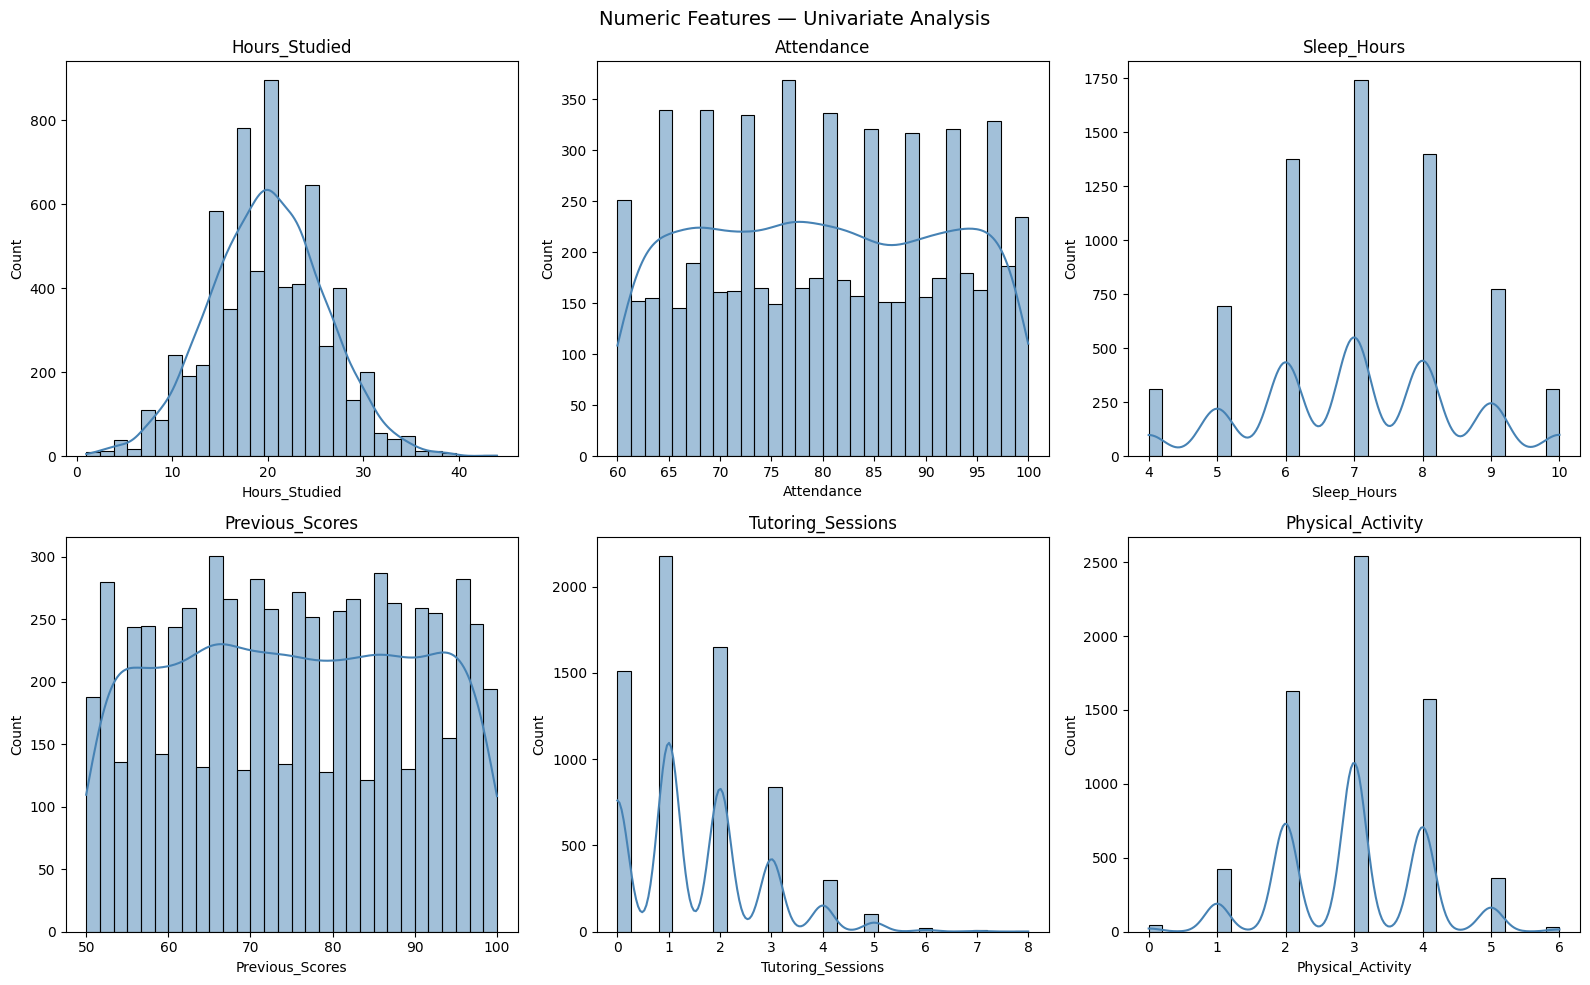

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

numeric_cols = ['Hours_Studied', 'Attendance', 'Sleep_Hours',
                'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.suptitle('Numeric Features — Univariate Analysis', fontsize=14)
plt.tight_layout()
plt.show()

- **Hours_Studied** — Right skew with a peak at 20 hours.
- **Attendance** — Values are evenly spread between 60–100 (uniform distribution).
- **Sleep_Hours** — Normal distribution with a peak at 7 hours.
- **Previous_Scores** — Values are relatively equal across the range (uniform distribution).
- **Tutoring_Sessions** — Right skew. Most students attend 0–2 sessions per month.
- **Physical_Activity** — Normal distribution with a peak at 3 hours per week.

All columns contain discrete (whole number) values. This causes a
"round number effect" — values like 20, 25, 30 are chosen more
frequently than others, creating a wavy pattern in the distributions.

The unusually clean and symmetric distributions across all columns
suggest this is a synthetic dataset. Real-world data would be
significantly noisier and less uniform. This does not affect the
analytical value but should be kept in mind when interpreting results.

# Categorical Features — Univariate Analysis

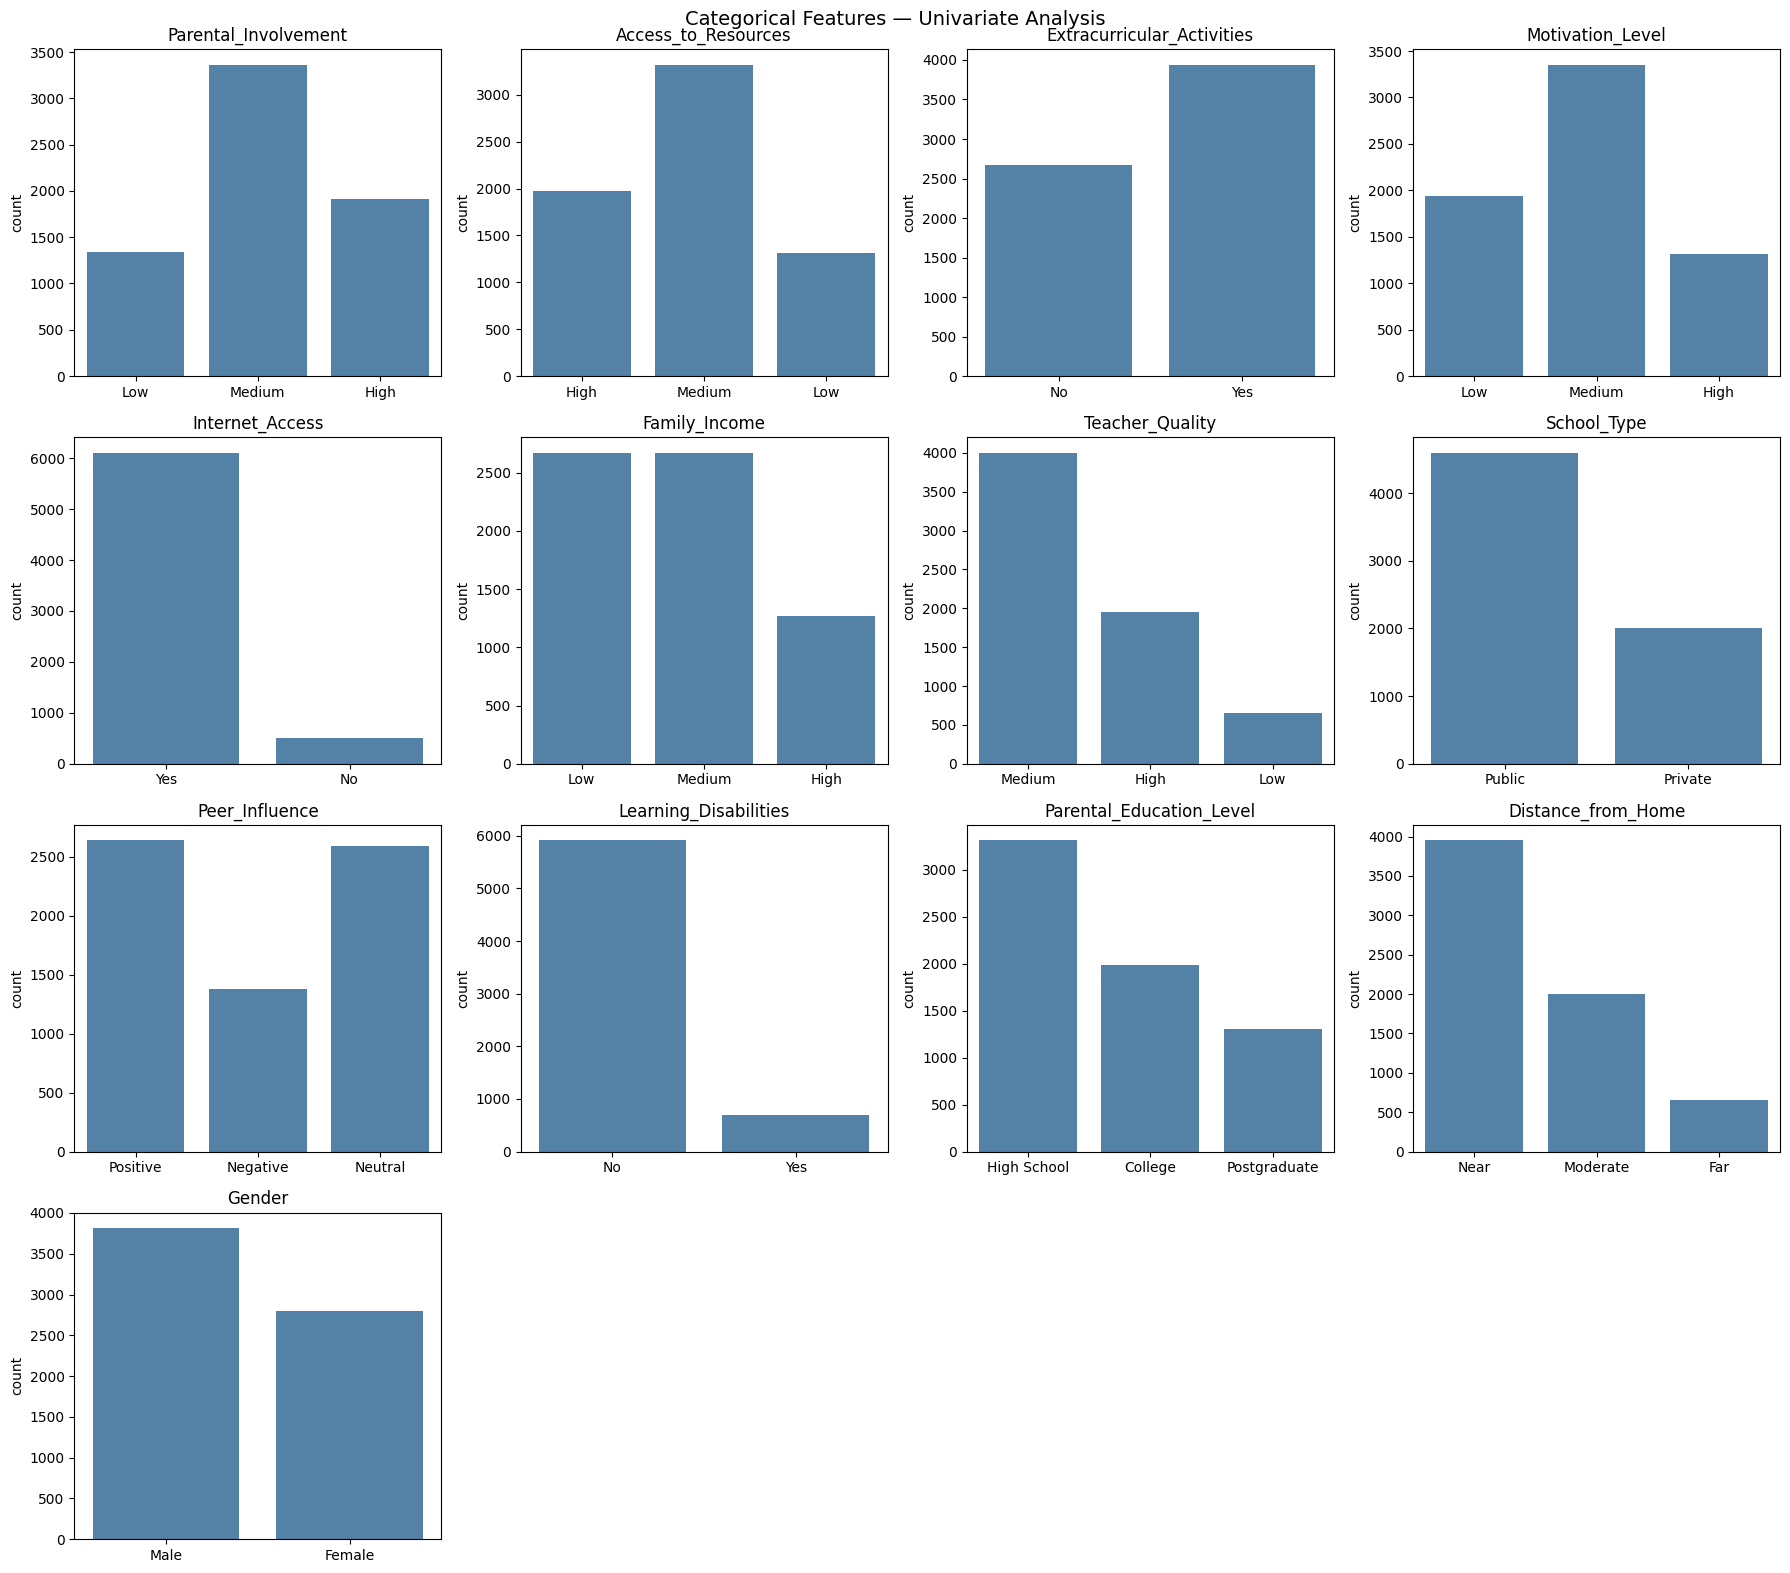

In [ ]:
categorical_cols = ['Parental_Involvement', 'Access_to_Resources',
                    'Extracurricular_Activities', 'Motivation_Level',
                    'Internet_Access', 'Family_Income', 'Teacher_Quality',
                    'School_Type', 'Peer_Influence', 'Learning_Disabilities',
                    'Parental_Education_Level', 'Distance_from_Home', 'Gender']

fig, axes = plt.subplots(4, 4, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(x=df[col], ax=axes[i], color='steelblue')
    axes[i].set_title(col)
    axes[i].set_xlabel('')

for j in range(len(categorical_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Features — Univariate Analysis', fontsize=14)
plt.tight_layout()
plt.show()

- **Parental_Involvement & Access_to_Resources & Motivation_Level &
  Teacher_Quality** — Medium dominates in all four columns, followed
  by High then Low. Notably, Low motivation outnumbers High motivation,
  which is a concerning pattern.

- **Extracurricular_Activities** — 60% of students participate, 40% do not.

- **Internet_Access** — Nearly universal (92.5% Yes), reflecting modern
  access trends.

- **Family_Income** — Low and Medium are nearly equal and together
  represent the vast majority of students. High income is significantly
  less common, which may partly explain why most students attend few
  tutoring sessions — a connection that will be explored in the
  multivariate analysis.

- **School_Type** — Public schools represent ~70% of students.

- **Peer_Influence** — Positive and Neutral are roughly equal, Negative
  accounts for only ~21% — a relatively encouraging finding.

- **Learning_Disabilities** — Only ~10.5% of students have a learning
  disability, consistent with real-world prevalence.

- **Parental_Education_Level** — High School is the most common,
  followed by College and Postgraduate, suggesting most parents
  have a basic level of education.

- **Distance_from_Home** — Most students live near their school (~59%),
  with progressively fewer at moderate and far distances.

- **Gender** — Male students slightly outnumber Female students
  (~3800 vs ~2800).

# Numeric Features vs Exam Score — Correlation Analysis

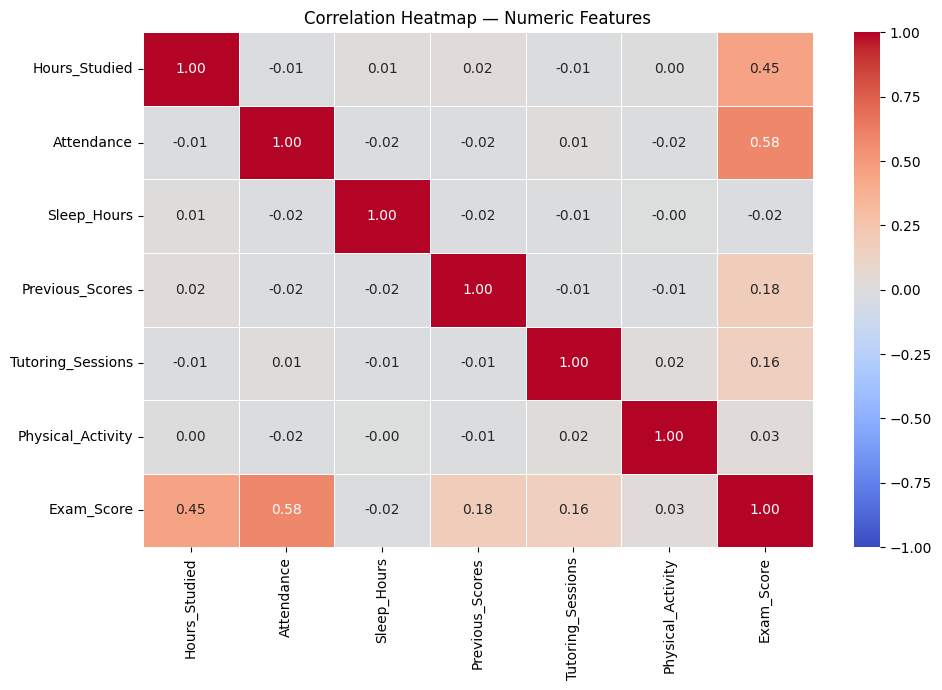

In [ ]:
corr = df[['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
           'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.show()

- Attendance (0.58) and Hours_Studied (0.45) are the strongest
  predictors of exam performance — showing up and studying matter most.

- Previous_Scores (0.18) and Tutoring_Sessions (0.16) show weak
  positive relationships.

- Sleep_Hours and Physical_Activity show virtually no correlation —
  likely a limitation of the synthetic dataset.

- No multicollinearity detected between independent variables.

# Categorical Features vs Exam Score — Bivariate Analysis

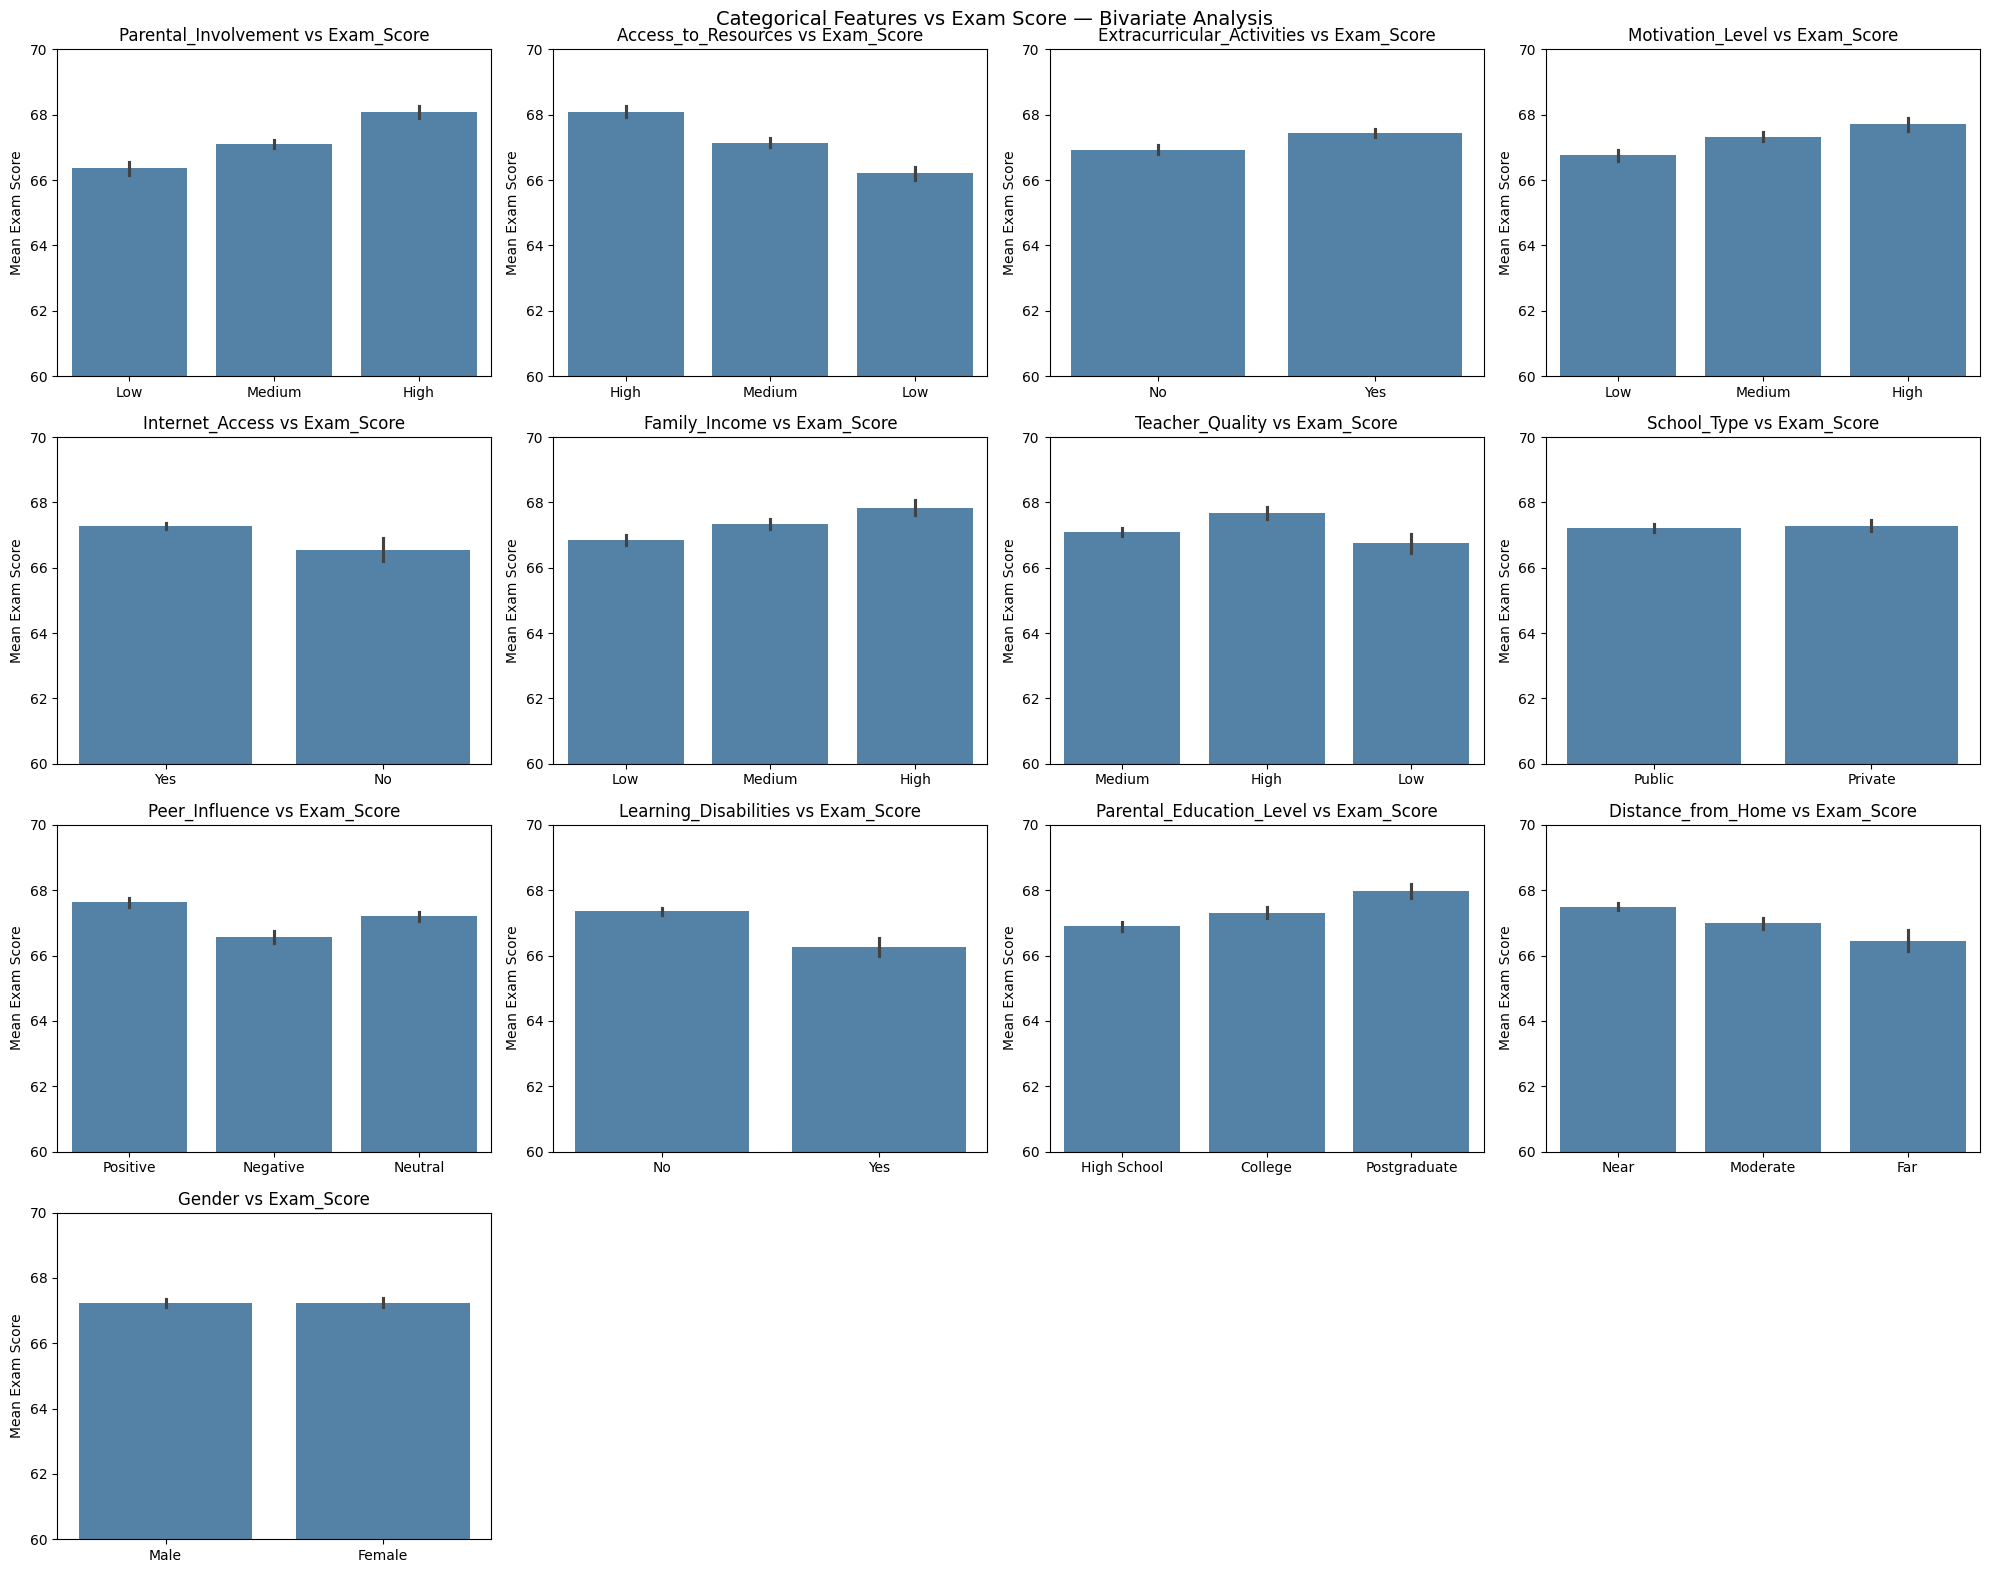

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

categorical_cols = ['Parental_Involvement', 'Access_to_Resources',
                    'Extracurricular_Activities', 'Motivation_Level',
                    'Internet_Access', 'Family_Income', 'Teacher_Quality',
                    'School_Type', 'Peer_Influence', 'Learning_Disabilities',
                    'Parental_Education_Level', 'Distance_from_Home', 'Gender']

for i, col in enumerate(categorical_cols):
    sns.barplot(x=df[col], y=df['Exam_Score'], ax=axes[i], color='steelblue')
    axes[i].set_title(f'{col} vs Exam_Score')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Mean Exam Score')
    axes[i].set_ylim(60, 70)

for j in range(len(categorical_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Features vs Exam Score — Bivariate Analysis', fontsize=14)
plt.tight_layout()
plt.show()

- Parental_Involvement, Access_to_Resources, Motivation_Level, and
  Parental_Education_Level all show a consistent pattern: higher levels
  are associated with higher exam scores, suggesting that a supportive
  environment positively influences performance.

- Access_to_Resources has a stronger effect than Internet_Access,
  suggesting that having study materials matters more than internet
  access alone.

- Teacher_Quality shows an interesting pattern: high quality teachers
  provide a measurable advantage, but the difference between medium
  and low quality is minimal — indicating that when teacher quality
  is not ideal, student performance depends largely on the student's
  own effort and habits.

- Learning_Disabilities, Distance_from_Home, and Peer_Influence show
  small but consistent effects — disabilities and distance negatively
  affect scores, while positive peer influence provides a slight boost.

- Gender and School_Type show virtually no difference in mean exam score.

- Crucially, all differences across categorical features are within
  2–3 points. This confirms that behavioral factors (attendance, study
  hours) are far stronger predictors of exam performance than
  environmental factors (family, school, income).

# Attendance — Deep Dive Analysis

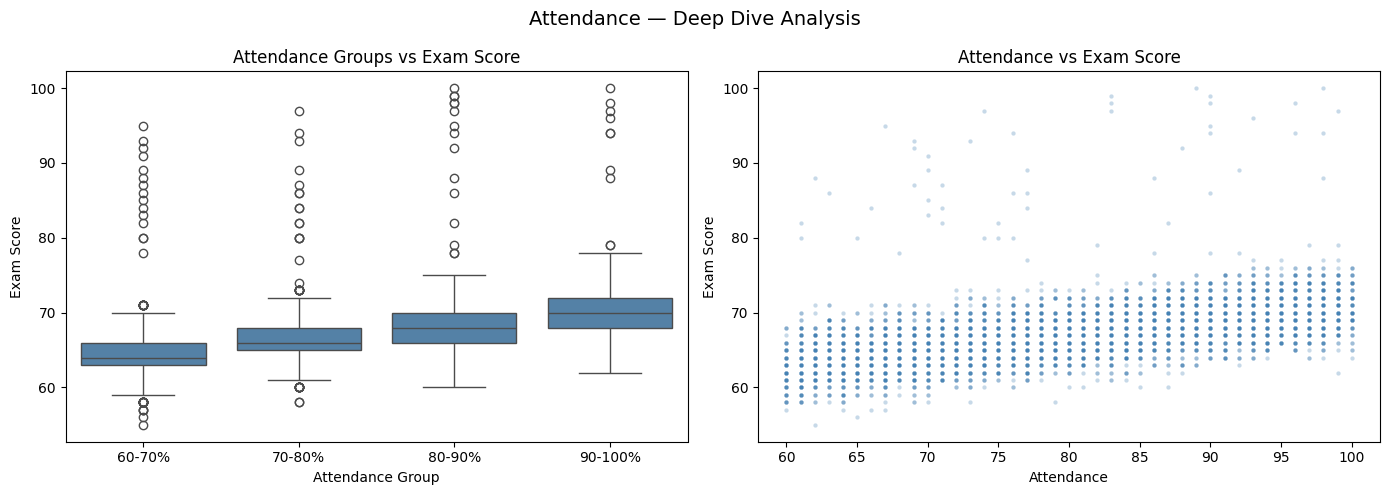

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['Attendance_Group'] = pd.cut(df['Attendance'],
                                 bins=[60, 70, 80, 90, 100],
                                 labels=['60-70%', '70-80%', '80-90%', '90-100%'])

sns.boxplot(x=df['Attendance_Group'], y=df['Exam_Score'],
            ax=axes[0], color='steelblue')
axes[0].set_title('Attendance Groups vs Exam Score')
axes[0].set_xlabel('Attendance Group')
axes[0].set_ylabel('Exam Score')

sns.scatterplot(x=df['Attendance'], y=df['Exam_Score'],
                ax=axes[1], alpha=0.3, color='steelblue', s=10)
axes[1].set_title('Attendance vs Exam Score')
axes[1].set_xlabel('Attendance')
axes[1].set_ylabel('Exam Score')

plt.suptitle('Attendance — Deep Dive Analysis', fontsize=14)
plt.tight_layout()
plt.show()

- Attendance shows a clear positive relationship with exam scores —
  median scores rise consistently from the 60-70% group to the 90-100% group.

- The 60-70% group shows the highest variability, with some students
  still scoring above 90. This may suggest compensation through higher
  study hours outside class.

- Consistent attendance (80%+) acts as a safety net — very low scores
  (below 60) almost disappear in higher attendance groups.

- Note: whether students missed class by choice or circumstance cannot
  be determined from this data and should be treated as a hypothesis only.

# Hours Studied — Deep Dive Analysis


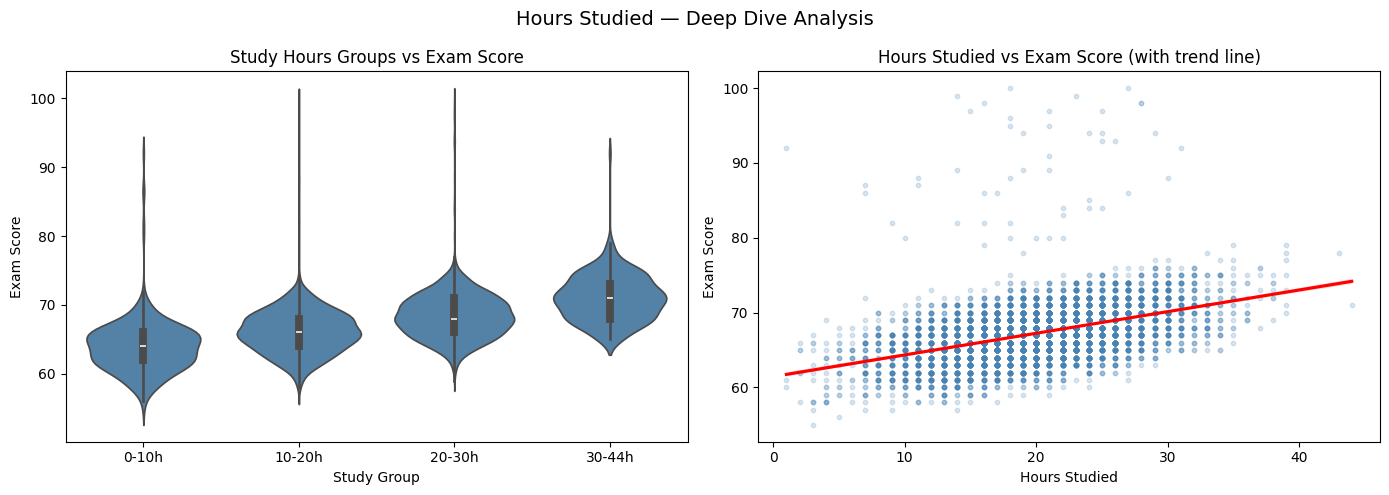

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['Study_Group'] = pd.cut(df['Hours_Studied'],
                            bins=[0, 10, 20, 30, 44],
                            labels=['0-10h', '10-20h', '20-30h', '30-44h'])

sns.violinplot(x=df['Study_Group'], y=df['Exam_Score'],
               ax=axes[0], color='steelblue')
axes[0].set_title('Study Hours Groups vs Exam Score')
axes[0].set_xlabel('Study Group')
axes[0].set_ylabel('Exam Score')

sns.regplot(x=df['Hours_Studied'], y=df['Exam_Score'],
            ax=axes[1], scatter_kws={'alpha': 0.2, 's': 10},
            line_kws={'color': 'red'}, color='steelblue')
axes[1].set_title('Hours Studied vs Exam Score (with trend line)')
axes[1].set_xlabel('Hours Studied')
axes[1].set_ylabel('Exam Score')

plt.suptitle('Hours Studied — Deep Dive Analysis', fontsize=14)
plt.tight_layout()
plt.show()

- Students studying 0-10 hours per week consistently score the lowest,
  while the 10-30 hour range represents the sweet spot for high performance.

- Students scoring 90+ are most commonly found in the 17-28 hour range,
  suggesting that quality and consistency matter more than raw hours.

- The 30-44h group shows fewer top scores (95+) than the 20-30h group —
  a clear sign of diminishing returns. Beyond 30 hours, additional study
  time shows no clear benefit, indicating that other factors become
  more important.

- One student achieved 90+ with near-zero study hours — likely a
  data entry error and not a meaningful pattern.


# Access to Resources — Deep Dive Analysis

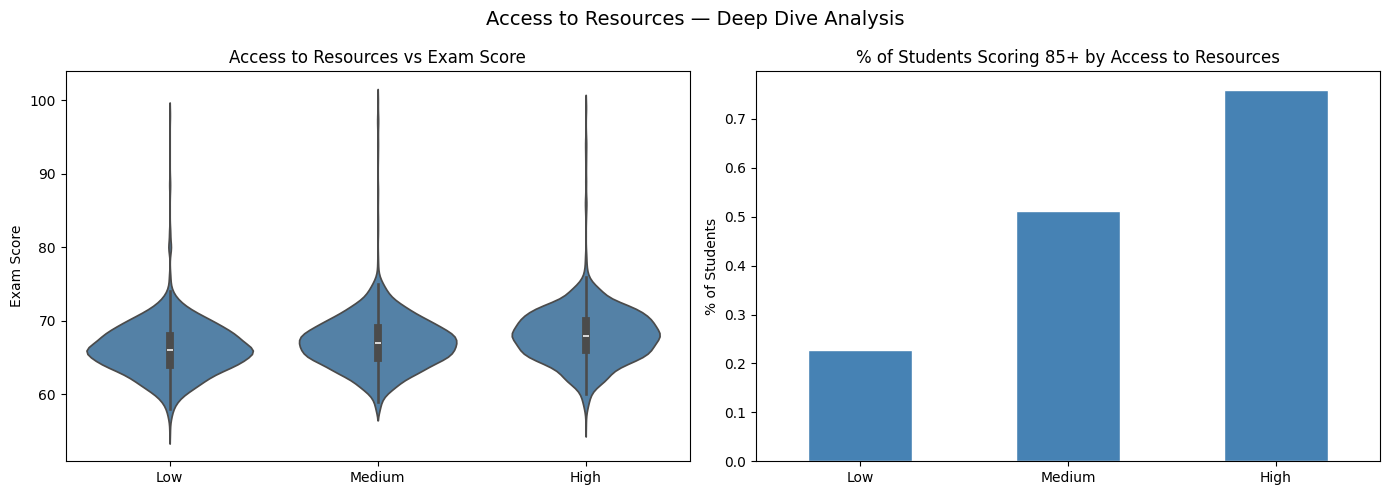

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = ['Low', 'Medium', 'High']

sns.violinplot(x=df['Access_to_Resources'], y=df['Exam_Score'],
               ax=axes[0], color='steelblue', order=order)
axes[0].set_title('Access to Resources vs Exam Score')
axes[0].set_xlabel('')
axes[0].set_ylabel('Exam Score')

total = df.groupby('Access_to_Resources')['Exam_Score'].count()
high = df[df['Exam_Score'] >= 85].groupby('Access_to_Resources')['Exam_Score'].count()
pct = (high / total * 100).reindex(order)

pct.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('% of Students Scoring 85+ by Access to Resources')
axes[1].set_xlabel('')
axes[1].set_ylabel('% of Students')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Access to Resources — Deep Dive Analysis', fontsize=14)
plt.tight_layout()
plt.show()

- For average students, access to resources shows minimal impact —
  violin plots across all three groups are nearly identical.

- However, among high scorers (85+), a clear pattern emerges:
  students with high resource access are approximately 3x more likely
  to score 85+ compared to those with low access (0.75% vs 0.23%).

- This suggests that resources matter most at the top end of
  performance — they may not lift average students significantly,
  but they appear to be an important enabler for exceptional results.

# Learning Disabilities — Deep Dive Analysis

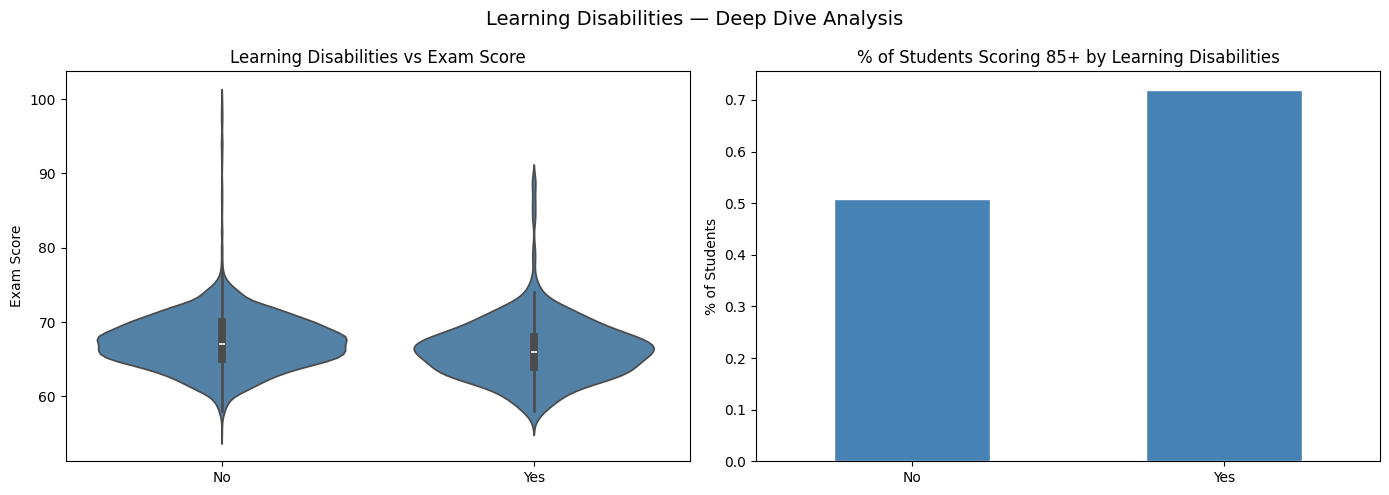

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.violinplot(x=df['Learning_Disabilities'], y=df['Exam_Score'],
               ax=axes[0], color='steelblue', order=['No', 'Yes'])
axes[0].set_title('Learning Disabilities vs Exam Score')
axes[0].set_xlabel('')
axes[0].set_ylabel('Exam Score')

total = df.groupby('Learning_Disabilities')['Exam_Score'].count()
high = df[df['Exam_Score'] >= 85].groupby('Learning_Disabilities')['Exam_Score'].count()
pct = (high / total * 100).reindex(['No', 'Yes'])

pct.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('% of Students Scoring 85+ by Learning Disabilities')
axes[1].set_xlabel('')
axes[1].set_ylabel('% of Students')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Learning Disabilities — Deep Dive Analysis', fontsize=14)
plt.tight_layout()
plt.show()

- Students without learning disabilities show a wider score range,
  including scores above 90 and up to 100, while students with
  disabilities appear capped around 85-90.

- Surprisingly, students with learning disabilities show a slightly
  higher percentage of 85+ scorers than those without. This may suggest
  that students with disabilities compensate through greater effort and
  determination — however, this should be treated as a hypothesis given
  the small sample size (695 students with disabilities).

- The combination of both visualizations was key here: the violin plot
  revealed the score ceiling effect, while the bar chart uncovered the
  unexpected pattern among high scorers — neither alone would have told
  the full story.

# Attendance + Hours Studied — Multivariate Analysis

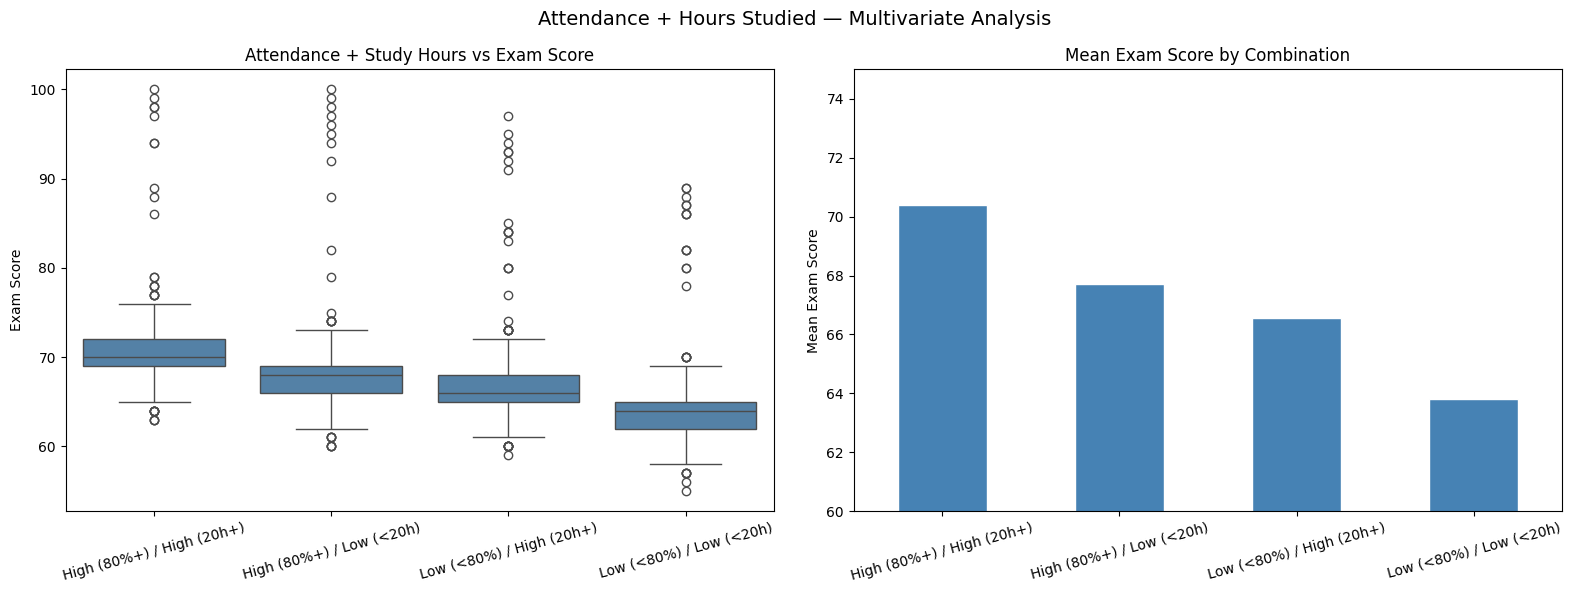

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df['Attendance_Level'] = df['Attendance'].apply(
    lambda x: 'High (80%+)' if x >= 80 else 'Low (<80%)')

df['Study_Level'] = df['Hours_Studied'].apply(
    lambda x: 'High (20h+)' if x >= 20 else 'Low (<20h)')

df['Combined'] = df['Attendance_Level'] + ' / ' + df['Study_Level']

order = ['High (80%+) / High (20h+)', 'High (80%+) / Low (<20h)',
         'Low (<80%) / High (20h+)', 'Low (<80%) / Low (<20h)']

sns.boxplot(x=df['Combined'], y=df['Exam_Score'],
            ax=axes[0], color='steelblue', order=order)
axes[0].set_title('Attendance + Study Hours vs Exam Score')
axes[0].set_xlabel('')
axes[0].set_ylabel('Exam Score')
axes[0].tick_params(axis='x', rotation=15)

df.groupby('Combined')['Exam_Score'].mean().reindex(order).plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Mean Exam Score by Combination')
axes[1].set_xlabel('')
axes[1].set_ylabel('Mean Exam Score')
axes[1].set_ylim(60, 75)
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Attendance + Hours Studied — Multivariate Analysis', fontsize=14)
plt.tight_layout()
plt.show()

- Students with both high attendance (80%+) and high study hours (20h+)
  achieve the highest mean score (~70.3) and the narrowest score range,
  meaning this combination produces not just better but more consistent
  and predictable performance.

- Attendance proves more critical than study hours: high attendance with
  low study hours (67.7) outperforms low attendance with high study hours
  (~66.4). This suggests that classroom learning — through teacher
  explanations, discussions, and Q&A — is more effective than studying alone.

- Top scores (90+) appear in both high-attendance groups regardless of
  study hours, but almost disappear when attendance is low — confirming
  attendance as the primary enabler of exceptional performance.

- When both factors are low, performance drops to ~63.8 with some students
  falling below 60, making this the highest-risk combination by far.

# Family Income + Access to Resources — Multivariate Analysis


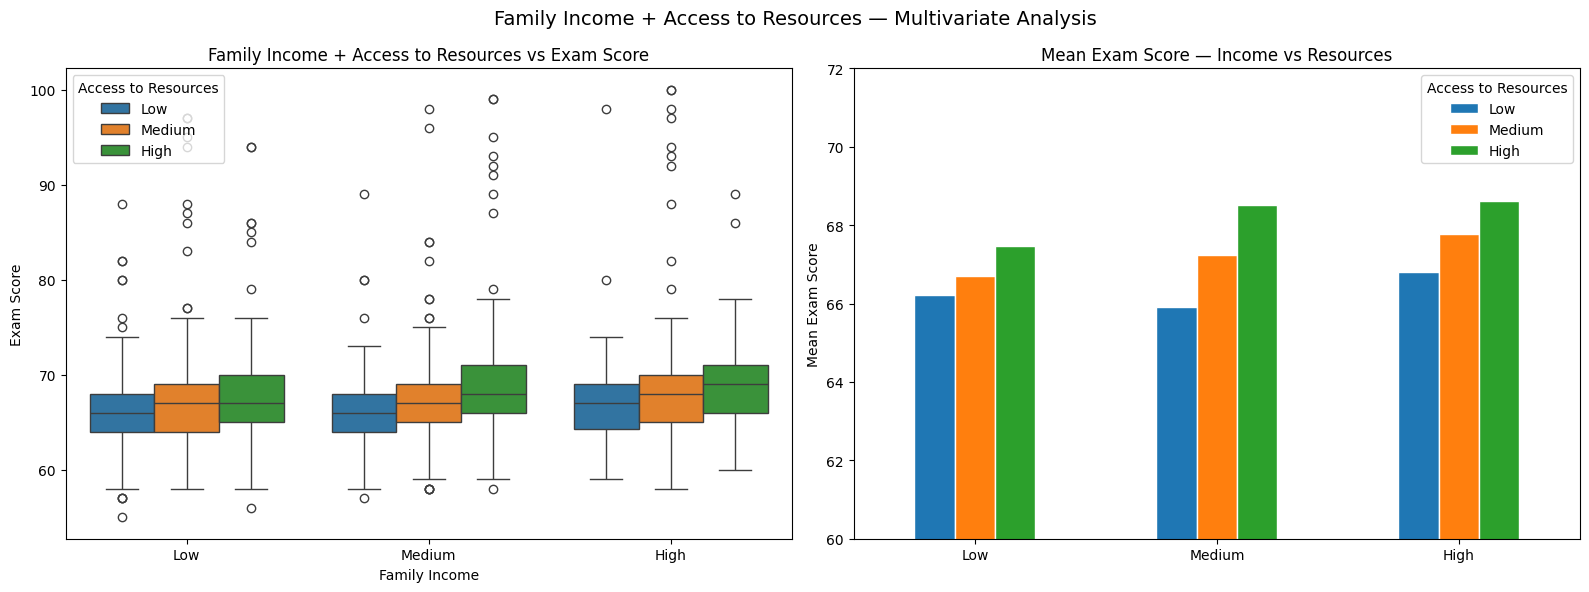

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

order = ['Low', 'Medium', 'High']

sns.boxplot(x=df['Family_Income'], y=df['Exam_Score'],
            hue=df['Access_to_Resources'],
            ax=axes[0], order=order, hue_order=order)
axes[0].set_title('Family Income + Access to Resources vs Exam Score')
axes[0].set_xlabel('Family Income')
axes[0].set_ylabel('Exam Score')
axes[0].legend(title='Access to Resources')

pivot = df.groupby(['Family_Income', 'Access_to_Resources'])['Exam_Score'].mean().unstack()
pivot.reindex(order)[order].plot(kind='bar', ax=axes[1], edgecolor='white')
axes[1].set_title('Mean Exam Score — Income vs Resources')
axes[1].set_xlabel('')
axes[1].set_ylabel('Mean Exam Score')
axes[1].set_ylim(60, 72)
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Access to Resources')

plt.suptitle('Family Income + Access to Resources — Multivariate Analysis', fontsize=14)
plt.tight_layout()
plt.show()

- Across all income levels, Access to Resources consistently drives
  exam scores upward — high resource access produces the best mean
  scores regardless of family income level.

- This reveals an important finding: resource access can partially
  compensate for lower income. A low-income student with high resource
  access performs comparably to a medium-income student, suggesting
  that providing educational resources may be more impactful than
  income alone.

- Family income on its own shows minimal direct effect on exam scores —
  the key differentiator within each income group is always the level
  of resource access.

- Note: the apparently low number of high scorers in the High income +
  High resources group is likely a reflection of the smaller sample
  size in that group rather than a meaningful pattern.

# Motivation Level + Hours Studied — Multivariate Analysis

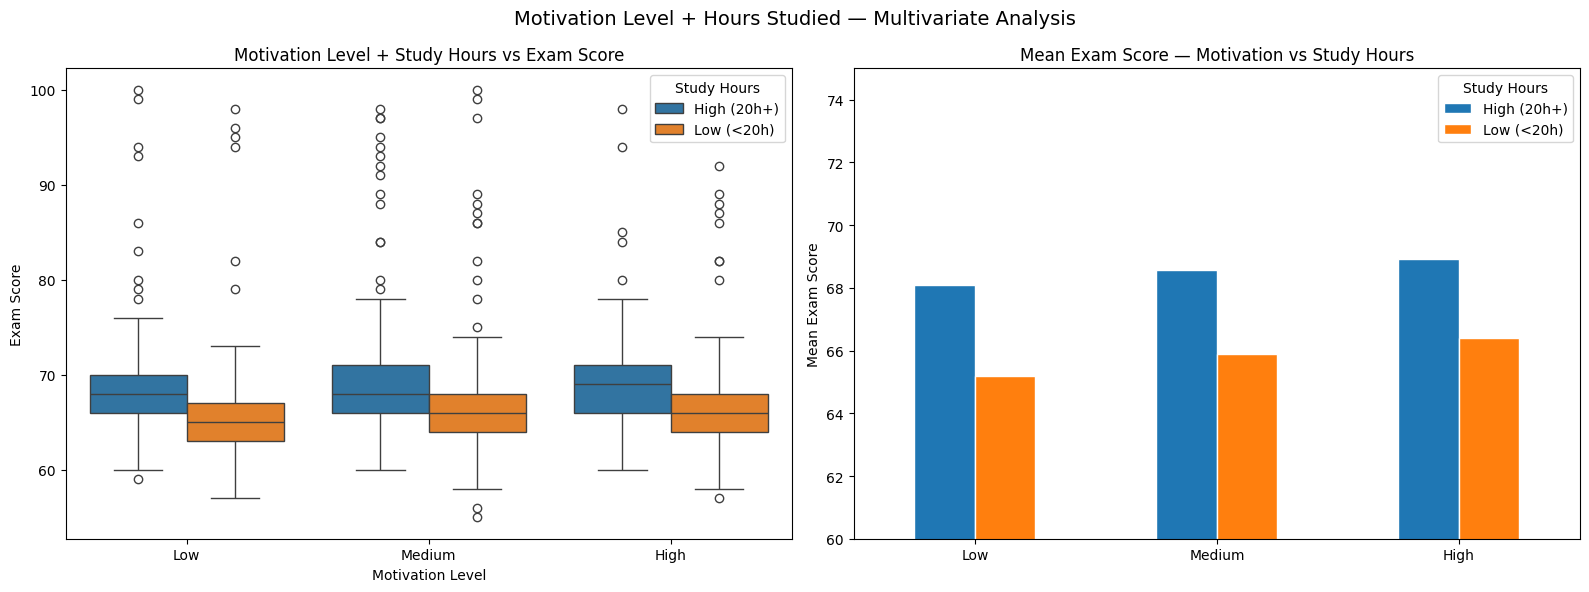

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

order = ['Low', 'Medium', 'High']

sns.boxplot(x=df['Motivation_Level'], y=df['Exam_Score'],
            hue=df['Study_Level'],
            ax=axes[0], order=order)
axes[0].set_title('Motivation Level + Study Hours vs Exam Score')
axes[0].set_xlabel('Motivation Level')
axes[0].set_ylabel('Exam Score')
axes[0].legend(title='Study Hours')

pivot = df.groupby(['Motivation_Level', 'Study_Level'])['Exam_Score'].mean().unstack()
pivot.reindex(order).plot(kind='bar', ax=axes[1], edgecolor='white')
axes[1].set_title('Mean Exam Score — Motivation vs Study Hours')
axes[1].set_xlabel('')
axes[1].set_ylabel('Mean Exam Score')
axes[1].set_ylim(60, 75)
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Study Hours')

plt.suptitle('Motivation Level + Hours Studied — Multivariate Analysis', fontsize=14)
plt.tight_layout()
plt.show()

- Across all motivation levels, high study hours (20h+) consistently
  outperforms low study hours — confirming that effort matters
  regardless of how motivated a student feels.

- Notably, low motivation + high study hours (68.1) performs similarly
  to high motivation + low study hours (66.3). This suggests that
  consistent effort can compensate for low motivation, but motivation
  alone without sufficient study hours is not enough.

- The gap between high and low study hours remains roughly constant
  across all motivation levels (~3 points), suggesting that motivation
  and study hours act independently rather than amplifying each other.

- Key takeaway: action beats intention — a less motivated student who
  studies consistently will outperform a highly motivated student
  who studies little.

# Teacher Quality + School Type — Multivariate Analysis

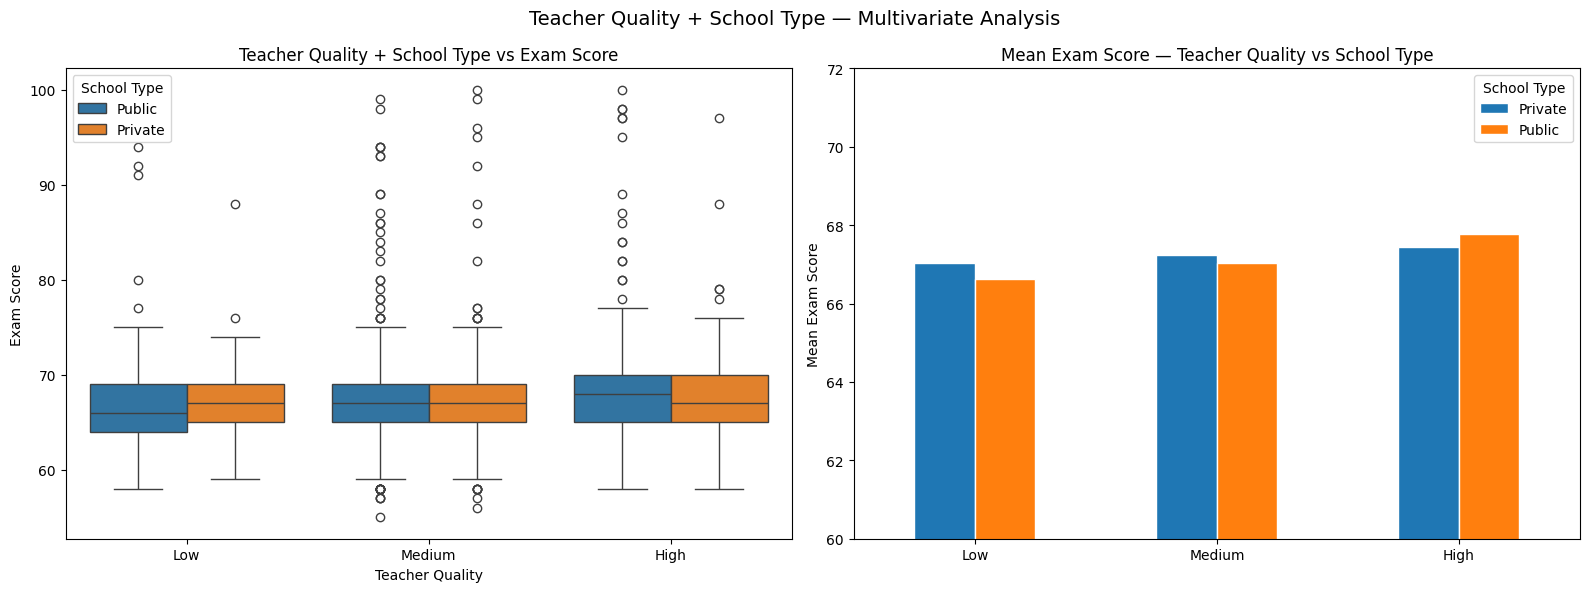

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

order = ['Low', 'Medium', 'High']

sns.boxplot(x=df['Teacher_Quality'], y=df['Exam_Score'],
            hue=df['School_Type'],
            ax=axes[0], order=order)
axes[0].set_title('Teacher Quality + School Type vs Exam Score')
axes[0].set_xlabel('Teacher Quality')
axes[0].set_ylabel('Exam Score')
axes[0].legend(title='School Type')

pivot = df.groupby(['Teacher_Quality', 'School_Type'])['Exam_Score'].mean().unstack()
pivot.reindex(order).plot(kind='bar', ax=axes[1], edgecolor='white')
axes[1].set_title('Mean Exam Score — Teacher Quality vs School Type')
axes[1].set_xlabel('')
axes[1].set_ylabel('Mean Exam Score')
axes[1].set_ylim(60, 72)
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='School Type')

plt.suptitle('Teacher Quality + School Type — Multivariate Analysis', fontsize=14)
plt.tight_layout()
plt.show()

- Teacher quality is the primary driver here — mean scores rise
  consistently as quality improves, and this trend holds for both
  public and private schools.

- School type has minimal impact. A slight private school advantage
  appears only at the high teacher quality level — in all other cases
  the difference is negligible.

- The wide score ranges and numerous outliers at medium and high quality
  levels confirm that teacher quality alone is not sufficient —
  student motivation, resources, and study habits still play a role.

- Notably, teacher quality appeared weak in bivariate analysis, but
  becomes clearer here when combined with school type — demonstrating
  the value of multivariate analysis in uncovering hidden patterns.

# Parental Involvement + Education Level — Multivariate Analysis

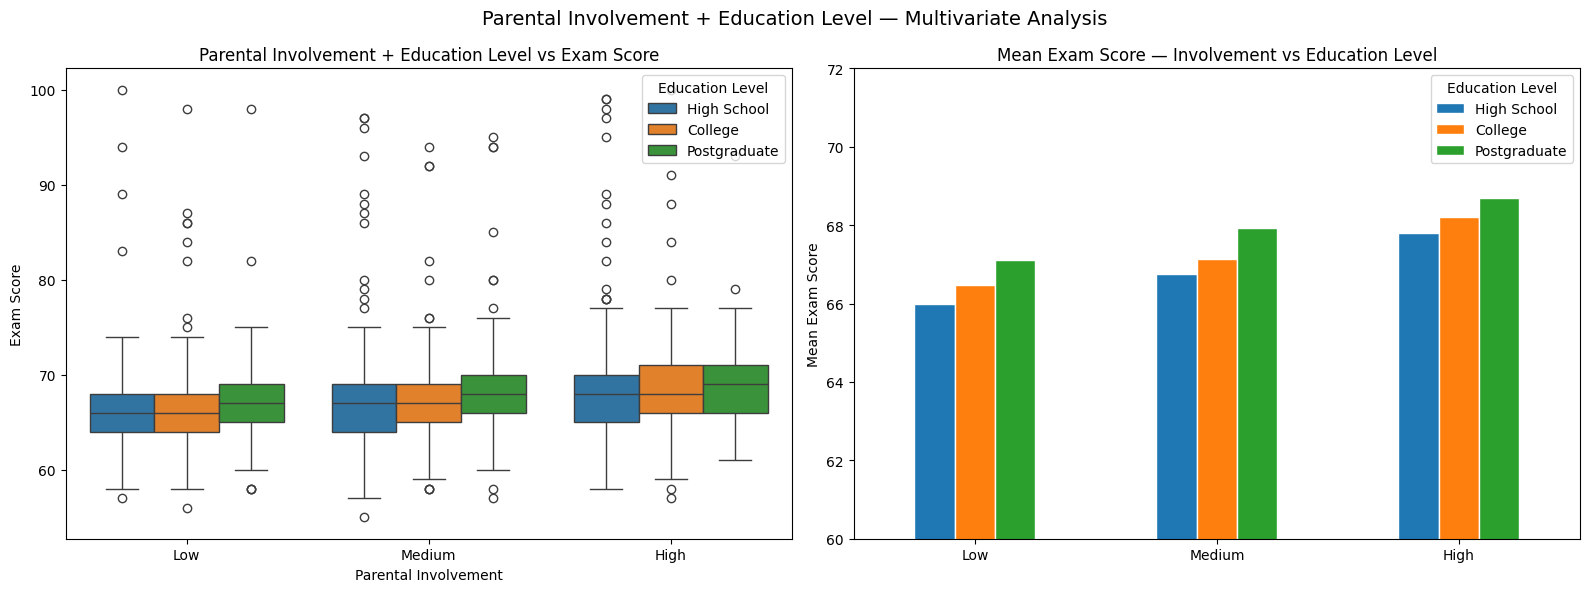

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

order_inv = ['Low', 'Medium', 'High']
order_edu = ['High School', 'College', 'Postgraduate']

sns.boxplot(x=df['Parental_Involvement'], y=df['Exam_Score'],
            hue=df['Parental_Education_Level'],
            ax=axes[0], order=order_inv, hue_order=order_edu)
axes[0].set_title('Parental Involvement + Education Level vs Exam Score')
axes[0].set_xlabel('Parental Involvement')
axes[0].set_ylabel('Exam Score')
axes[0].legend(title='Education Level')

pivot = df.groupby(['Parental_Involvement', 'Parental_Education_Level'])['Exam_Score'].mean().unstack()
pivot.reindex(order_inv)[order_edu].plot(kind='bar', ax=axes[1], edgecolor='white')
axes[1].set_title('Mean Exam Score — Involvement vs Education Level')
axes[1].set_xlabel('')
axes[1].set_ylabel('Mean Exam Score')
axes[1].set_ylim(60, 72)
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Education Level')

plt.suptitle('Parental Involvement + Education Level — Multivariate Analysis', fontsize=14)
plt.tight_layout()
plt.show()

- Parental involvement remains the primary driver — scores rise
  consistently across all education levels as involvement increases.

- Within each involvement level, parental education acts as a
  secondary multiplier: postgraduate parents consistently produce
  the highest scoring students, followed by college, then high school.

- This suggests that education level influences the quality of parental
  support — more educated parents may provide better academic guidance,
  resource selection, and study direction rather than simply spending
  more time with their children.

- Importantly, the overlapping distributions confirm this is not
  deterministic — a child of a high school educated parent can still
  outperform a child of a postgraduate parent, indicating that
  involvement quality matters more than education credentials alone.


# Final Conclusion

This analysis examined the behavioral, environmental, and personal factors
influencing student exam performance across a dataset of 6,607 students.

The central finding is clear: **student behavior drives outcomes more than
circumstances.** Attendance (r=0.58) and study hours (r=0.45) were by far
the strongest predictors of exam performance — far outweighing background
factors such as family income, school type, or parental education.

## Key Findings

**Attendance is the single most important factor.**
Students with 80%+ attendance virtually eliminated the risk of very low
scores and consistently achieved higher medians. High attendance with low
study hours still outperformed low attendance with high study hours —
confirming that classroom learning is irreplaceable.

**The optimal study range is 15–30 hours per week.**
Top scores (90+) were most concentrated in the 17–28 hour range. Beyond
30 hours, diminishing returns set in — excessive study time did not
translate into better results, suggesting that quality and consistency
matter more than raw volume.

**Effort compensates for motivation — not the other way around.**
Students with low motivation but high study hours consistently outperformed
highly motivated students who studied little. Action beats intention.

**Resource access matters most at the top.**
For average performers, environmental factors showed minimal impact.
However, students with high resource access were approximately 3x more
likely to score 85+ — making resources a critical enabler of exceptional,
rather than average, performance. Resource access also partially
compensated for lower family income.

**Environmental factors are secondary but compounding.**
Parental involvement, teacher quality, and parental education each
contributed modest individual effects. However, their combination acted
as a multiplier — students benefiting from high involvement and
postgraduate-educated parents achieved the most consistent improvements.

## Limitations

The dataset shows characteristics of synthetic data — unusually clean
distributions and a round-number effect — which may understate real-world
noise and variability. Findings should be interpreted as directionally
valid rather than precisely quantified.

## Bottom Line

The profile of a high-performing student is defined primarily by
controllable behaviors: showing up consistently and studying within a
productive range. Supportive environments help — especially for reaching
the top — but cannot substitute for personal discipline. For students,
educators, and policymakers alike, the most impactful interventions
remain the simplest: improve attendance and build consistent study habits.